In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
train_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/train_dataset_v8_slope.csv"
)

test_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/test_dataset_v8_slope.csv"
)

print(train_dataset.shape)
print(test_dataset.shape)

(242965, 206)
(66060, 206)


In [4]:
behavior_map = {
    "NORMAL1": "NORMAL",
    "NORMAL2": "NORMAL"
}

train_dataset["behavior"] = (
    train_dataset["behavior"]
    .replace(behavior_map)
)

test_dataset["behavior"] = (
    test_dataset["behavior"]
    .replace(behavior_map)
)

print(train_dataset["behavior"].value_counts())
print()
print(test_dataset["behavior"].value_counts())

behavior
NORMAL        116203
AGGRESSIVE     63761
DROWSY         63001
Name: count, dtype: int64

behavior
DROWSY        36143
AGGRESSIVE    15257
NORMAL        14660
Name: count, dtype: int64


In [5]:
target_column = "behavior"

feature_columns = [

    col

    for col in train_dataset.columns

    if col not in [

        "behavior",
        "driver",
        "trip",
        "road_type"

    ]

]

X_train = train_dataset[feature_columns]
X_test = test_dataset[feature_columns]

y_train = train_dataset[target_column]
y_test = test_dataset[target_column]

print(X_train.shape)
print(X_test.shape)

(242965, 202)
(66060, 202)


In [6]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


In [7]:
xgb_model = XGBClassifier(

    random_state=42,

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="multi:softmax",

    num_class=3,

    eval_metric="mlogloss"

)

In [8]:
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost v8 trained successfully!")

XGBoost v8 trained successfully!


In [9]:
xgb_pred = xgb_model.predict(
    X_test
)

xgb_pred[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [10]:
accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6814


In [11]:
print(

    classification_report(

        y_test,

        xgb_pred,

        target_names=label_encoder.classes_

    )

)

              precision    recall  f1-score   support

  AGGRESSIVE       0.87      0.83      0.85     15257
      DROWSY       0.90      0.54      0.68     36143
      NORMAL       0.43      0.86      0.57     14660

    accuracy                           0.68     66060
   macro avg       0.73      0.75      0.70     66060
weighted avg       0.79      0.68      0.69     66060



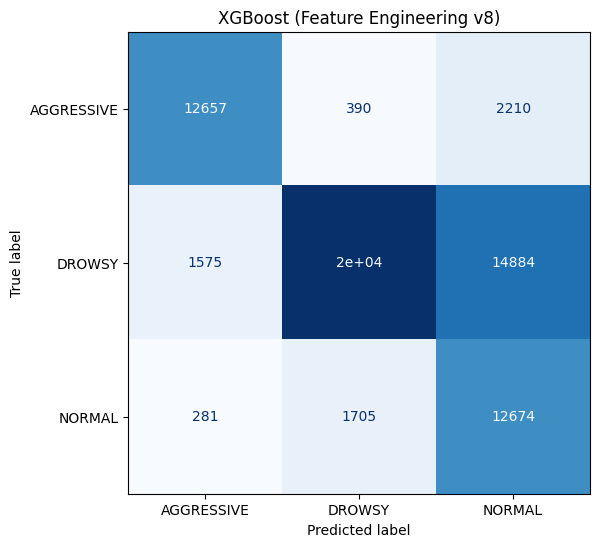

In [13]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("XGBoost (Feature Engineering v8)")

plt.show()